<a href="https://colab.research.google.com/github/DhimanTarafdar/gallbladder_cancer_research/blob/main/Gallbladder_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install** and load required packages

In [1]:
!pip install rpy2 --quiet

import pandas as pd
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, numpy2ri, r
from rpy2.robjects.packages import importr

# Install R packages (only needs to run once per session)
robjects.r('''
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager", repos="http://cran.r-project.org")
BiocManager::install(c("limma", "edgeR"), update = FALSE, ask = FALSE)
''')

limma = importr('limma')
pandas2ri.activate()
numpy2ri.activate()
print("Setup done ✅")

(as ‘lib’ is unspecified)







	‘/tmp/Rtmp84TwJO/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com











	‘/tmp/Rtmp84TwJO/downloaded_packages’



Setup done ✅


# **Load GSE139682 (normalized RPKM data)**

In [11]:
df_139682 = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')

# Get normal and tumor sample columns automatically
normal_cols_139682 = [c for c in df_139682.columns if c.startswith('Normal')]
tumor_cols_139682  = [c for c in df_139682.columns if c.startswith('Tumor')]

print(f"GSE139682 -> Normal: {len(normal_cols_139682)}, Tumor: {len(tumor_cols_139682)}")

GSE139682 -> Normal: 10, Tumor: 10


# **Load GSE202479 (raw count data) + build labels**

In [12]:
def extract_full_metadata_line(series_matrix_path, keyword):
    # This function reads one metadata line from the series_matrix file
    with open(series_matrix_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(keyword):
                parts = line.strip().split('\t')
                parts = [p.strip('"') for p in parts]
                return parts[1:]  # skip the label, keep only values
    return None

import re

titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

# Map sample code (like N8, T1) to normal/tumor/exclude
label_map_202479 = {}
for title, tissue in zip(titles, tissue_type):
    code = re.search(r'\[(.*?)\]', title).group(1)
    tissue_clean = tissue.replace('tissue type: ', '').strip()
    if tissue_clean == 'normal gallbladder':
        label_map_202479[code] = 'normal'
    elif tissue_clean == 'advanced gallbladder cancer':
        label_map_202479[code] = 'tumor'
    else:
        label_map_202479[code] = 'exclude'   # skip inflammation, adenoma, early stage

# Build final column lists
normal_codes = [k for k, v in label_map_202479.items() if v == 'normal']
tumor_codes  = [k for k, v in label_map_202479.items() if v == 'tumor']

normal_cols_202479 = [f"{c}_count" for c in normal_codes]
tumor_cols_202479  = [f"{c}_count" for c in tumor_codes]

df_202479 = pd.read_csv('GSE202479_gene_expression_anno.txt', sep='\t')

print(f"GSE202479 -> Normal: {len(normal_cols_202479)}, Tumor: {len(tumor_cols_202479)}")

GSE202479 -> Normal: 3, Tumor: 5


In [13]:
selected_cols = ['Gene', 'Symbol'] + normal_cols_202479 + tumor_cols_202479

print(df_202479[normal_cols_202479 + tumor_cols_202479].head())

   N8_count  N10_count  N20_count  T1_count  T19_count  T22_count  T27_count  \
0         0          0          0         0          0          0          0   
1        86         56        175        25         30         42         38   
2      1176        975       1705      1151       1253       1631       1334   
3      1717       1582       2262      2152       1397       1729       3035   
4         3          2          5         1          0          4          7   

   T32_count  
0          0  
1         84  
2       1238  
3       4213  
4          0  


In [14]:
print("Dataset Shape:", df_202479.shape)


Dataset Shape: (50868, 50)


# **DEG analysis functions**

In [15]:
def run_limma_normalized(expr_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    # Use this for already-normalized data (like RPKM/FPKM)
    expr_matrix = expr_df[normal_cols + tumor_cols].values
    expr_matrix = np.log2(expr_matrix + 1)  # log transform, avoid log(0)

    genes = expr_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    r.assign('expr_mat', expr_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(expr_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)
    fit <- lmFit(expr_mat, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested")
    return result_df


def run_limma_voom(count_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    # Use this for raw count data
    count_matrix = count_df[normal_cols + tumor_cols].values
    genes = count_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    r.assign('count_mat', count_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(count_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)

    library(edgeR)
    dge <- DGEList(counts=count_mat)
    keep <- filterByExpr(dge, design)
    dge <- dge[keep,, keep.lib.sizes=FALSE]
    dge <- calcNormFactors(dge)

    v <- voom(dge, design)
    fit <- lmFit(v, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested (after low-expression filter)")
    return result_df

# **Run DEG analysis on both datasets**

In [16]:
deg_139682 = run_limma_normalized(df_139682, 'GeneID', normal_cols_139682, tumor_cols_139682, "GSE139682")
deg_202479 = run_limma_voom(df_202479, 'gene_id', normal_cols_202479, tumor_cols_202479, "GSE202479")

GSE139682: 41762 genes tested


GSE202479: 21273 genes tested (after low-expression filter)


# **Filter significant DEGs**

In [17]:
def filter_significant_degs(deg_df, logfc_col='logFC', padj_col='adj.P.Val',
                              logfc_thresh=1, padj_thresh=0.05):
    # Keep only genes that are statistically significant AND have a strong fold change
    sig = deg_df[(deg_df[padj_col] < padj_thresh) & (deg_df[logfc_col].abs() > logfc_thresh)]
    print(f"Significant DEGs: {sig.shape[0]} out of {deg_df.shape[0]}")
    return sig

sig_139682 = filter_significant_degs(deg_139682)
sig_202479 = filter_significant_degs(deg_202479)

Significant DEGs: 650 out of 41762
Significant DEGs: 1033 out of 21273


# **Map all gene IDs to Symbol (common gene naming system)**

In [18]:
df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t', low_memory=False)
ensembl_to_symbol = dict(zip(df_annot['EnsemblGeneID'], df_annot['Symbol']))

# GSE139682 already uses Symbol, no conversion needed
sig_139682_genes = set(sig_139682['GeneID'])

# GSE202479 uses Ensembl ID, convert to Symbol
sig_202479_genes = set(sig_202479['GeneID'].map(ensembl_to_symbol).dropna())

print(f"GSE139682 mapped genes: {len(sig_139682_genes)}")
print(f"GSE202479 mapped genes: {len(sig_202479_genes)}")

GSE139682 mapped genes: 650
GSE202479 mapped genes: 879


# **Find consensus DEGs (final feature pool)**

In [19]:
consensus_genes = sig_139682_genes & sig_202479_genes
print(f"\nFinal consensus DEG pool: {len(consensus_genes)} genes")
print(sorted(consensus_genes))

# Save this list -- this is the input for the next stage (ML feature selection)
consensus_df = pd.DataFrame({'Gene_Symbol': sorted(consensus_genes)})
consensus_df.to_csv('consensus_DEG_list.csv', index=False)
print("\nSaved consensus DEG list to 'consensus_DEG_list.csv'")


Final consensus DEG pool: 178 genes
['ABCA8', 'ABI3BP', 'ACSS3', 'ACTC1', 'ACTG2', 'ADAMTS1', 'ADAMTS8', 'ADAMTS9-AS2', 'ADCY5', 'ADRB3', 'AKAP6', 'ANGPT1', 'ANGPTL1', 'ANLN', 'AOX1', 'ARHGEF26', 'ASB2', 'ATAD2', 'ATOH8', 'ATP1A2', 'BIRC5', 'BUB1', 'C3orf70', 'CAB39L', 'CASQ2', 'CCDC3', 'CCKAR', 'CDH19', 'CDO1', 'CENPF', 'CFD', 'CHRM2', 'CKS2', 'CLEC3B', 'CLIP3', 'CNN1', 'CNTN1', 'COL4A6', 'CRYAB', 'CSPG4', 'DIAPH3', 'DIXDC1', 'DMD', 'DPT', 'DTNA', 'E2F1', 'ECT2', 'EFCC1', 'EFHD1', 'EML1', 'EPPK1', 'EVPL', 'EXO1', 'EZH2', 'FAM107A', 'FAM162B', 'FAXDC2', 'FCER1A', 'FENDRR', 'FGF2', 'FHL1', 'FILIP1', 'FOXF1', 'FREM1', 'FXYD1', 'FXYD6', 'GALNT16', 'GFRA1', 'GINS1', 'GLP2R', 'GPM6A', 'GPM6B', 'GPRASP1', 'GPX3', 'GUCY1B2', 'HBB', 'HDC', 'HLF', 'HMMR', 'HOXB5', 'HOXB7', 'HPSE2', 'HSPB6', 'HSPB7', 'HSPB8', 'IQGAP3', 'ITGA7', 'ITGA8', 'ITPR1', 'JPH2', 'KANK2', 'KCNAB1', 'KCNMA1', 'KCNMB1', 'KIF14', 'KIF18B', 'KIF4A', 'KLF15', 'KRT222', 'LAMB3', 'LIFR', 'LIMS2', 'LMOD1', 'MADCAM1', 'MAMDC2', '

# **Build combined expression matrix for the 178 consensus genes**

In [20]:
import pandas as pd
import numpy as np

# Load the consensus gene list
consensus_df = pd.read_csv('consensus_DEG_list.csv')
consensus_genes = consensus_df['Gene_Symbol'].tolist()
print(f"Total consensus genes: {len(consensus_genes)}")

# ---- GSE139682: already uses gene Symbol, so filter directly ----
expr_139682 = df_139682[df_139682['GeneID'].isin(consensus_genes)].copy()
expr_139682 = expr_139682.set_index('GeneID')[normal_cols_139682 + tumor_cols_139682]
expr_139682 = np.log2(expr_139682 + 1)   # log transform, same as DEG step

# ---- GSE202479: uses Ensembl ID, convert to Symbol first ----
df_202479_annot = df_202479.copy()
df_202479_annot['Symbol'] = df_202479_annot['gene_id'].map(ensembl_to_symbol)
expr_202479 = df_202479_annot[df_202479_annot['Symbol'].isin(consensus_genes)].copy()
expr_202479 = expr_202479.drop_duplicates(subset='Symbol')  # keep first if duplicate mapping
expr_202479 = expr_202479.set_index('Symbol')[normal_cols_202479 + tumor_cols_202479]
expr_202479 = np.log2(expr_202479 + 1)

print(f"GSE139682 matched genes: {expr_139682.shape[0]}")
print(f"GSE202479 matched genes: {expr_202479.shape[0]}")

# ---- Align gene order (keep only genes present in both, in same order) ----
common_genes = sorted(set(expr_139682.index) & set(expr_202479.index))
expr_139682 = expr_139682.loc[common_genes]
expr_202479 = expr_202479.loc[common_genes]
print(f"Genes present in both (final feature set): {len(common_genes)}")

# ---- Merge into one matrix (samples as rows, genes as columns) ----
combined_expr = pd.concat([expr_139682, expr_202479], axis=1).T
combined_expr['label'] = ['normal']*len(normal_cols_139682) + ['tumor']*len(tumor_cols_139682) + \
                          ['normal']*len(normal_cols_202479) + ['tumor']*len(tumor_cols_202479)
combined_expr['batch'] = ['GSE139682']*len(normal_cols_139682+tumor_cols_139682) + \
                          ['GSE202479']*len(normal_cols_202479+tumor_cols_202479)

print(combined_expr.shape)
combined_expr.head()

Total consensus genes: 178
GSE139682 matched genes: 178
GSE202479 matched genes: 178
Genes present in both (final feature set): 178
(28, 180)


,ABCA8,ABI3BP,ACSS3,ACTC1,ACTG2,ADAMTS1,ADAMTS8,ADAMTS9-AS2,ADCY5,ADRB3,...,TOP2A,TPX2,TRIP13,TTK,TUB,VIT,WFDC1,ZNF385D,label,batch
Normal 6,4.942227,5.205296,3.202292,1.326892,7.677738,7.581749,2.592949,3.564315,3.410379,2.353998,...,1.524688,1.418743,0.809668,0.622396,2.606595,1.734507,4.547673,2.871262,normal,GSE139682
Normal 10,4.371806,4.808659,3.238318,2.245756,7.289556,4.631507,1.715462,2.829241,2.785468,0.860702,...,3.934876,2.951988,1.600452,1.470186,2.451359,2.122420,3.841326,2.148791,normal,GSE139682
Normal 9,4.665683,5.740644,3.407746,1.620224,7.245167,4.991138,2.589896,3.224922,3.359682,1.281576,...,0.975046,0.905731,0.644589,0.385936,2.236801,2.225111,4.242748,2.124474,normal,GSE139682
Normal 5,2.876046,3.857076,3.990081,0.771108,6.084895,4.349181,1.951237,3.137343,2.571496,1.021908,...,3.755331,2.643173,1.725392,1.987760,1.587889,0.030057,3.914737,1.641704,normal,GSE139682
Normal 8,3.920152,5.552652,2.950316,0.845755,6.302570,6.314650,2.372144,2.422400,2.402837,0.769276,...,3.387820,2.867430,1.791870,2.283397,2.494483,0.982172,3.376777,2.383788,normal,GSE139682


# **Batch correction using ComBat (via Python's combat package)**

In [21]:
!pip install combat --quiet

from combat.pycombat import pycombat

# Separate the expression matrix from label/batch info
expr_only = combined_expr.drop(columns=['label', 'batch']).T   # genes x samples (combat expects this shape)
batch_labels = combined_expr['batch'].values

# Run ComBat batch correction
expr_corrected = pycombat(expr_only, batch_labels)

# Put back into samples x genes format
expr_corrected = expr_corrected.T
expr_corrected['label'] = combined_expr['label'].values
expr_corrected['batch'] = combined_expr['batch'].values

print(expr_corrected.shape)
expr_corrected.head()

  Preparing metadata (setup.py) ... done
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
(28, 180)


,ABCA8,ABI3BP,ACSS3,ACTC1,ACTG2,ADAMTS1,ADAMTS8,ADAMTS9-AS2,ADCY5,ADRB3,...,TOP2A,TPX2,TRIP13,TTK,TUB,VIT,WFDC1,ZNF385D,label,batch
Normal 6,6.958885,7.170486,4.876805,2.695719,9.225474,9.779108,4.600094,5.206950,5.384501,4.061525,...,2.948046,2.615595,1.888603,1.609637,4.391062,2.911368,6.125871,4.880376,normal,GSE139682
Normal 10,6.331040,6.747925,4.918467,3.836660,8.839676,6.630490,3.395747,4.374627,4.595056,2.123171,...,5.638826,4.483879,2.864903,2.608792,4.210066,3.374995,5.282440,3.963699,normal,GSE139682
Normal 9,6.654502,7.740826,5.114401,3.059946,8.795560,7.014303,4.595904,4.822656,5.320455,2.669481,...,2.334416,1.990481,1.684796,1.330958,3.959904,3.497730,5.761768,3.932846,normal,GSE139682
Normal 5,4.684702,5.734143,5.787840,2.005610,7.642414,6.329180,3.719347,4.723490,4.324746,2.332422,...,5.438378,4.107583,3.019153,3.218775,3.203312,0.874237,5.370098,3.320304,normal,GSE139682
Normal 8,5.833918,7.540547,4.585408,2.098299,7.858752,8.426809,4.297040,3.913963,4.111681,2.004496,...,5.028082,4.380844,3.101228,3.567195,4.260346,2.012190,4.727733,4.261865,normal,GSE139682


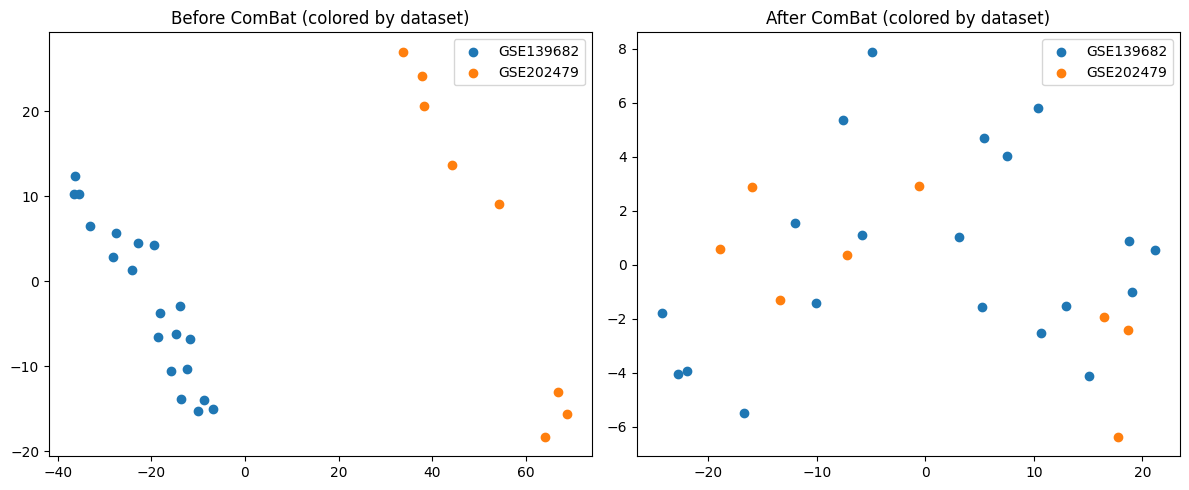

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = expr_corrected.drop(columns=['label', 'batch']).values
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before correction, colored by batch (dataset)
X_before = combined_expr.drop(columns=['label','batch']).values
coords_before = PCA(n_components=2).fit_transform(X_before)
for batch in combined_expr['batch'].unique():
    idx = combined_expr['batch'] == batch
    axes[0].scatter(coords_before[idx,0], coords_before[idx,1], label=batch)
axes[0].set_title('Before ComBat (colored by dataset)')
axes[0].legend()

# After correction, colored by batch
for batch in expr_corrected['batch'].unique():
    idx = expr_corrected['batch'] == batch
    axes[1].scatter(coords[idx,0], coords[idx,1], label=batch)
axes[1].set_title('After ComBat (colored by dataset)')
axes[1].legend()

plt.tight_layout()
plt.show()

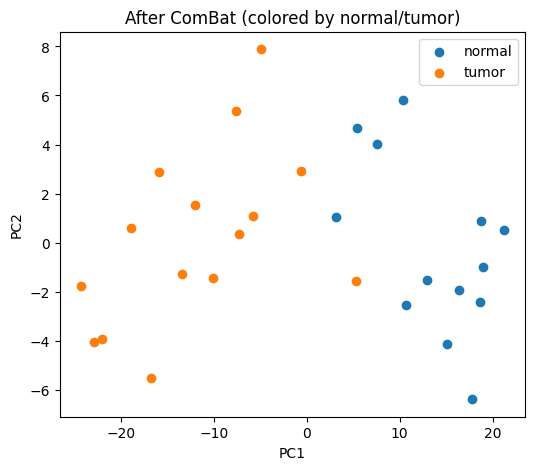

In [23]:
fig, ax = plt.subplots(figsize=(6,5))
for label in expr_corrected['label'].unique():
    idx = expr_corrected['label'] == label
    ax.scatter(coords[idx,0], coords[idx,1], label=label)
ax.set_title('After ComBat (colored by normal/tumor)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.show()

# **Prepare data (X = gene expression, y = label)**

In [24]:
from sklearn.preprocessing import LabelEncoder

X = expr_corrected.drop(columns=['label', 'batch']).values
gene_names = expr_corrected.drop(columns=['label', 'batch']).columns.tolist()
y = LabelEncoder().fit_transform(expr_corrected['label'].values)  # normal=0, tumor=1 (check order)

print(f"X shape: {X.shape}, y distribution: {np.bincount(y)}")

X shape: (28, 178), y distribution: [13 15]


# **Stability Selection using LASSO (bootstrap resampling)**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
import numpy as np

def stability_selection(X, y, gene_names, n_bootstrap=200, sample_frac=0.8, C=0.5):
    # This function repeats LASSO many times on random subsamples
    # and counts how often each gene gets a non-zero coefficient
    n_samples = X.shape[0]
    selection_counts = np.zeros(X.shape[1])

    for i in range(n_bootstrap):
        # Randomly pick a subset of samples (bootstrap without replacement)
        idx = resample(np.arange(n_samples), replace=False,
                        n_samples=int(sample_frac * n_samples),
                        stratify=y, random_state=i)
        X_sub, y_sub = X[idx], y[idx]

        # L1-penalized logistic regression (LASSO for classification)
        model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
        model.fit(X_sub, y_sub)

        # Mark which genes got non-zero coefficient this round
        selected = (np.abs(model.coef_[0]) > 1e-6)
        selection_counts += selected

    stability_scores = selection_counts / n_bootstrap
    result = pd.DataFrame({'Gene': gene_names, 'Stability_Score': stability_scores})
    result = result.sort_values('Stability_Score', ascending=False).reset_index(drop=True)
    return result

stability_result = stability_selection(X, y, gene_names)
print(stability_result.head(30))

# Keep genes selected in at least 70% of bootstrap rounds -- this is a strict, reliable cutoff
stable_genes = stability_result[stability_result['Stability_Score'] >= 0.7]['Gene'].tolist()
print(f"\nStable genes (selected in >=70% of resamples): {len(stable_genes)}")
print(stable_genes)

       Gene  Stability_Score
0     LAMB3            0.950
1       DPT            0.945
2     HOXB7            0.850
3     EPPK1            0.520
4     CENPF            0.480
5     ACTG2            0.345
6     TOP2A            0.320
7     MYH11            0.275
8     HOXB5            0.245
9      TPX2            0.140
10      CFD            0.130
11   COL4A6            0.100
12     ANLN            0.065
13    CHRM2            0.065
14    MKI67            0.060
15     MYOC            0.035
16   MAMDC2            0.030
17    ACTC1            0.030
18   FCER1A            0.030
19  GUCY1B2            0.030
20    GLP2R            0.020
21      HBB            0.015
22      OGN            0.010
23     FHL1            0.010
24     ECT2            0.005
25   ATP1A2            0.005
26     HMMR            0.005
27      HLF            0.005
28    CCDC3            0.000
29    CASQ2            0.000

Stable genes (selected in >=70% of resamples): 3
['LAMB3', 'DPT', 'HOXB7']


# **2nd validation angle — RFECV (Cross-Validated RFE)**

In [26]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

rf = RandomForestClassifier(n_estimators=300, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='roc_auc', min_features_to_select=5)
rfecv.fit(X, y)

rfe_genes = [gene_names[i] for i in range(len(gene_names)) if rfecv.support_[i]]
print(f"RFECV selected {len(rfe_genes)} genes: {rfe_genes}")


# ============================================================
# FINAL: Combine both methods -- genes confirmed by BOTH approaches
# ============================================================
final_panel = list(set(stable_genes) & set(rfe_genes))
print(f"\nFinal robust gene panel (confirmed by both methods): {len(final_panel)}")
print(final_panel)

RFECV selected 46 genes: ['ACTG2', 'ATP1A2', 'CAB39L', 'CCDC3', 'CFD', 'CHRM2', 'CLEC3B', 'CNTN1', 'COL4A6', 'CRYAB', 'DMD', 'DPT', 'FHL1', 'FOXF1', 'FXYD1', 'GLP2R', 'HLF', 'ITGA7', 'LIMS2', 'MAMDC2', 'MYH11', 'MYOC', 'NUF2', 'PDE2A', 'PGM5', 'PKIG', 'POPDC2', 'RBPMS2', 'RCAN2', 'RNF150', 'RORB', 'SGCA', 'SH3BP5', 'SKA3', 'SORBS1', 'SOX5', 'SUSD5', 'SYNM', 'SYNPO2', 'TGFBR3', 'TLCD1', 'TMOD1', 'TNXB', 'TPX2', 'VIT', 'WFDC1']

Final robust gene panel (confirmed by both methods): 1
['DPT']


# **Rank Aggregation: combine Stability Selection + RFECV ranking**

In [27]:
# Stability score itself acts as one ranking (higher = better)
stability_rank = stability_result.set_index('Gene')['Stability_Score']

# RFECV gives a ranking too (1 = selected/best, higher number = eliminated earlier)
rfecv_ranking = pd.Series(rfecv.ranking_, index=gene_names)
# Convert to a 0-1 score where higher is better (invert ranking)
rfecv_score = 1 / rfecv_ranking   # rank 1 -> score 1.0, rank 50 -> score 0.02

# Combine both scores (simple average of normalized scores)
combined = pd.DataFrame({
    'Gene': gene_names,
    'Stability_Score': [stability_rank.get(g, 0) for g in gene_names],
    'RFECV_Score': [rfecv_score.get(g, 0) for g in gene_names]
})

# Normalize each score to 0-1 range before combining (fair comparison)
combined['Stability_norm'] = combined['Stability_Score'] / combined['Stability_Score'].max()
combined['RFECV_norm'] = combined['RFECV_Score'] / combined['RFECV_Score'].max()
combined['Combined_Score'] = (combined['Stability_norm'] + combined['RFECV_norm']) / 2

combined = combined.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
print(combined.head(20)[['Gene', 'Stability_Score', 'RFECV_Score', 'Combined_Score']])

# Take top 10-15 genes as the final panel
final_panel = combined.head(12)['Gene'].tolist()
print(f"\nFinal gene panel (top 12 by combined rank): {final_panel}")

      Gene  Stability_Score  RFECV_Score  Combined_Score
0      DPT            0.945     1.000000        0.997368
1    ACTG2            0.345     1.000000        0.681579
2    MYH11            0.275     1.000000        0.644737
3     TPX2            0.140     1.000000        0.573684
4      CFD            0.130     1.000000        0.568421
5   COL4A6            0.100     1.000000        0.552632
6    CHRM2            0.065     1.000000        0.534211
7     MYOC            0.035     1.000000        0.518421
8   MAMDC2            0.030     1.000000        0.515789
9    GLP2R            0.020     1.000000        0.510526
10   LAMB3            0.950     0.015385        0.507692
11    FHL1            0.010     1.000000        0.505263
12     HLF            0.005     1.000000        0.502632
13  ATP1A2            0.005     1.000000        0.502632
14  CAB39L            0.000     1.000000        0.500000
15   CCDC3            0.000     1.000000        0.500000
16  CLEC3B            0.000    

# FIX: Use Random Forest feature importance (continuous score)
# instead of RFECV's coarse selected/not-selected ranking


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_full = RandomForestClassifier(n_estimators=500, random_state=42)
rf_full.fit(X, y)

rf_importance = pd.Series(rf_full.feature_importances_, index=gene_names)

# Rebuild the combined ranking using RF importance instead of RFECV ranking
combined2 = pd.DataFrame({
    'Gene': gene_names,
    'Stability_Score': [stability_rank.get(g, 0) for g in gene_names],
    'RF_Importance': [rf_importance.get(g, 0) for g in gene_names]
})

combined2['Stability_norm'] = combined2['Stability_Score'] / combined2['Stability_Score'].max()
combined2['RF_norm'] = combined2['RF_Importance'] / combined2['RF_Importance'].max()
combined2['Combined_Score'] = (combined2['Stability_norm'] + combined2['RF_norm']) / 2

combined2 = combined2.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
print(combined2.head(20)[['Gene', 'Stability_Score', 'RF_Importance', 'Combined_Score']])

final_panel = combined2.head(12)['Gene'].tolist()
print(f"\nFinal gene panel (top 12, fixed ranking): {final_panel}")

      Gene  Stability_Score  RF_Importance  Combined_Score
0      DPT            0.945       0.028840        0.892366
1    ACTG2            0.345       0.036507        0.681579
2    LAMB3            0.950       0.003054        0.541834
3    HOXB7            0.850       0.002000        0.474761
4     FHL1            0.010       0.034269        0.474617
5     PGM5            0.000       0.032267        0.441927
6   TGFBR3            0.000       0.030000        0.410882
7     TNXB            0.000       0.029451        0.403357
8   SYNPO2            0.000       0.026931        0.368846
9    CNTN1            0.000       0.026803        0.367090
10   RCAN2            0.000       0.026000        0.356098
11   MYH11            0.275       0.013731        0.332795
12  COL4A6            0.100       0.019733        0.322901
13   CHRM2            0.065       0.019769        0.304972
14   EPPK1            0.520       0.002000        0.301076
15   FOXF1            0.000       0.020275        0.2776

# **Evaluate final gene panel using Nested Cross-Validation**

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import numpy as np

final_panel = ['DPT', 'ACTG2', 'LAMB3', 'HOXB7', 'FHL1', 'PGM5',
               'TGFBR3', 'TNXB', 'SYNPO2', 'CNTN1', 'RCAN2', 'MYH11']

# Subset X to only the final panel genes
gene_idx = [gene_names.index(g) for g in final_panel]
X_final = X[:, gene_idx]

print(f"Final data shape for evaluation: {X_final.shape}")

# Outer loop: 5-fold cross-validation (honest performance estimate)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_final, y, cv=outer_cv, scoring='roc_auc')
    print(f"{name}: AUC = {scores.mean():.3f} (+/- {scores.std():.3f}) | folds: {np.round(scores,3)}")

Final data shape for evaluation: (28, 12)
Random Forest: AUC = 1.000 (+/- 0.000) | folds: [1. 1. 1. 1. 1.]
SVM (linear): AUC = 1.000 (+/- 0.000) | folds: [1. 1. 1. 1. 1.]
Logistic Regression: AUC = 1.000 (+/- 0.000) | folds: [1. 1. 1. 1. 1.]


# CORRECT APPROACH: Nested Cross-Validation
# (feature selection happens INSIDE each training fold only)

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# Use the FULL 178-gene consensus set here, not the pre-selected 12 genes
X_full = expr_corrected.drop(columns=['label', 'batch']).values
gene_names_full = expr_corrected.drop(columns=['label', 'batch']).columns.tolist()

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def select_top_genes_by_rf(X_train, y_train, gene_names, top_n=12):
    # Feature selection using ONLY the training fold's data
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    importance = pd.Series(rf.feature_importances_, index=gene_names)
    top_genes = importance.sort_values(ascending=False).head(top_n).index.tolist()
    return top_genes

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {name: [] for name in models}
selected_genes_per_fold = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_full, y)):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Feature selection using ONLY this fold's training data
    top_genes = select_top_genes_by_rf(X_train, y_train, gene_names_full, top_n=12)
    selected_genes_per_fold.append(top_genes)

    gene_idx = [gene_names_full.index(g) for g in top_genes]
    X_train_sub = X_train[:, gene_idx]
    X_test_sub = X_test[:, gene_idx]

    for name, model in models.items():
        model.fit(X_train_sub, y_train)
        prob = model.predict_proba(X_test_sub)[:,1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_sub)
        auc = roc_auc_score(y_test, prob)
        results[name].append(auc)

    print(f"Fold {fold_i+1} selected genes: {top_genes}")

print("\n--- Honest (leakage-free) performance ---")
for name, scores in results.items():
    print(f"{name}: AUC = {np.mean(scores):.3f} (+/- {np.std(scores):.3f}) | folds: {np.round(scores,3)}")

Fold 1 selected genes: ['TNXB', 'FOXF1', 'ATP1A2', 'PGM5', 'FGF2', 'RORB', 'RCAN2', 'FHL1', 'CNTN1', 'JPH2', 'HLF', 'ACTC1']
Fold 2 selected genes: ['PDE8B', 'ACTG2', 'PGM5', 'COL4A6', 'TGFBR3', 'WFDC1', 'HLF', 'CNTN1', 'EPPK1', 'MAMDC2', 'ATP1A2', 'CHRM2']
Fold 3 selected genes: ['MYH11', 'GPX3', 'RSPO1', 'TNXB', 'CHRM2', 'LIFR', 'GFRA1', 'LAMB3', 'KCNAB1', 'EVPL', 'ECT2', 'ACTG2']
Fold 4 selected genes: ['ACTG2', 'PGM5', 'CNTN1', 'ATP1A2', 'RCAN2', 'POPDC2', 'TGFBR3', 'DPT', 'HLF', 'TNXB', 'CCDC3', 'MYH11']
Fold 5 selected genes: ['PGM5', 'RCAN2', 'CNTN1', 'HLF', 'ACTG2', 'FHL1', 'DPT', 'MYH11', 'WFDC1', 'ATP1A2', 'FOXF1', 'MRGPRF']

--- Honest (leakage-free) performance ---
Random Forest: AUC = 0.956 (+/- 0.089) | folds: [1.    1.    0.778 1.    1.   ]
SVM (linear): AUC = 0.956 (+/- 0.089) | folds: [1.    1.    0.778 1.    1.   ]
Logistic Regression: AUC = 0.956 (+/- 0.089) | folds: [1.    1.    0.778 1.    1.   ]


In [31]:
from collections import Counter

all_selected = [gene for fold_genes in selected_genes_per_fold for gene in fold_genes]
gene_freq = Counter(all_selected)

freq_df = pd.DataFrame(gene_freq.items(), columns=['Gene', 'Fold_Count']).sort_values('Fold_Count', ascending=False)
print(freq_df.to_string(index=False))

  Gene  Fold_Count
ATP1A2           4
 ACTG2           4
  PGM5           4
 CNTN1           4
   HLF           4
  TNXB           3
 RCAN2           3
 MYH11           3
  FHL1           2
TGFBR3           2
 WFDC1           2
 CHRM2           2
 FOXF1           2
   DPT           2
 PDE8B           1
  RORB           1
  FGF2           1
COL4A6           1
  JPH2           1
 ACTC1           1
MAMDC2           1
  GPX3           1
 RSPO1           1
  LIFR           1
 EPPK1           1
 GFRA1           1
 LAMB3           1
  EVPL           1
KCNAB1           1
  ECT2           1
POPDC2           1
 CCDC3           1
MRGPRF           1


# **GSE13223 Load and create Subset**

In [32]:
# Load GSE13223 expression file
df_13223 = pd.read_csv('GSE132223_norm_counts_TPM_GRCh38.p13_NCBI.tsv', sep='\t')

# Extract metadata for labeling (already know the mapping from before)
label_map_13223 = {
    'GSM3854440': 'normal', 'GSM3854441': 'tumor', 'GSM3854442': 'exclude',
    'GSM3854443': 'normal', 'GSM3854444': 'tumor', 'GSM3854445': 'exclude',
    'GSM3854446': 'normal', 'GSM3854447': 'tumor', 'GSM3854448': 'exclude'
}

normal_samples_13223 = [k for k, v in label_map_13223.items() if v == 'normal']
tumor_samples_13223  = [k for k, v in label_map_13223.items() if v == 'tumor']

print("Normal:", normal_samples_13223)
print("Tumor:", tumor_samples_13223)

# Build the subset (GeneID + normal + tumor columns only, exclude metastasis)
df_13223_subset = df_13223[['GeneID'] + normal_samples_13223 + tumor_samples_13223]
print(df_13223_subset.shape)   # expect (39376, 7)
df_13223_subset.head()

Normal: ['GSM3854440', 'GSM3854443', 'GSM3854446']
Tumor: ['GSM3854441', 'GSM3854444', 'GSM3854447']
(39376, 7)


,GeneID,GSM3854440,GSM3854443,GSM3854446,GSM3854441,GSM3854444,GSM3854447
0,100287102,0.6333,0.6472,0.3103,0.1205,0.5185,0.02507
1,653635,17.6000,15.5600,13.7400,4.4080,14.3300,6.35600
2,102466751,19.0800,26.2000,13.5700,5.1810,23.3300,1.82700
3,107985730,0.0000,0.1104,0.0000,0.0000,0.2359,0.00000
4,100302278,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000


# **Annotation file load**

In [33]:
df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t', low_memory=False)
entrez_to_symbol = dict(zip(df_annot['GeneID'].astype(str), df_annot['Symbol']))

# **EXTERNAL VALIDATION on GSE13223 (completely unseen dataset)**

In [34]:
final_panel = ['ATP1A2', 'PGM5', 'CNTN1', 'HLF', 'ACTG2']  # core 5-gene panel
# or extended: final_panel += ['TNXB', 'RCAN2', 'MYH11']

# Map GSE13223's Entrez IDs to Symbol (needed since GSE13223 uses Entrez GeneID)
entrez_to_symbol = dict(zip(df_annot['GeneID'].astype(str), df_annot['Symbol']))
df_13223_subset_annot = df_13223_subset.copy()
df_13223_subset_annot['Symbol'] = df_13223_subset_annot['GeneID'].astype(str).map(entrez_to_symbol)

# Filter to the final panel genes only
expr_13223_final = df_13223_subset_annot[df_13223_subset_annot['Symbol'].isin(final_panel)]
expr_13223_final = expr_13223_final.set_index('Symbol')[normal_samples_13223 + tumor_samples_13223]
expr_13223_final = np.log2(expr_13223_final + 1)

print(f"Genes found in GSE13223 (out of {len(final_panel)}): {expr_13223_final.shape[0]}")
print(expr_13223_final)

Genes found in GSE13223 (out of 5): 5
        GSM3854440  GSM3854443  GSM3854446  GSM3854441  GSM3854444  GSM3854447
Symbol                                                                        
ATP1A2    4.448901    3.766595    4.344828    0.476952    0.866315    0.288063
ACTG2     7.417009    5.648178    8.414051    3.386811    6.596935    3.605257
PGM5      4.056584    3.304511    4.726286    1.448901    1.549423    0.924176
CNTN1     3.958843    0.886121    4.079805    1.341417    1.495183    0.066923
HLF       3.146818    1.118360    3.856986    0.280125    0.429750    0.530370


# TRAIN on discovery data (GSE139682+GSE202479),
# TEST on completely independent GSE13223

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

final_panel = ['ATP1A2', 'PGM5', 'CNTN1', 'HLF', 'ACTG2']

# ---- Training data: from batch-corrected combined discovery set ----
X_train_df = expr_corrected[final_panel]
y_train = LabelEncoder().fit_transform(expr_corrected['label'].values)  # normal=0, tumor=1

# ---- Test data: GSE13223 (independent, never used in training or feature selection) ----
X_test_df = expr_13223_final.T[final_panel]  # samples as rows, genes as columns
y_test = np.array([0,0,0,1,1,1])  # normal, normal, normal, tumor, tumor, tumor (matches column order)

# Standardize using training data's scaler (avoid leakage: fit only on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df.values)
X_test_scaled = scaler.transform(X_test_df.values)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

# ---- Train and evaluate multiple models ----
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")
    print(f"Predictions: {y_pred}, Actual: {y_test}")

Train shape: (28, 5) | Test shape: (6, 5)

--- Random Forest ---
Accuracy: 0.500, AUC: 1.000
Predictions: [1 1 1 1 1 1], Actual: [0 0 0 1 1 1]

--- SVM (linear) ---
Accuracy: 0.667, AUC: 1.000
Predictions: [1 1 0 1 1 1], Actual: [0 0 0 1 1 1]

--- Logistic Regression ---
Accuracy: 0.667, AUC: 1.000
Predictions: [1 1 0 1 1 1], Actual: [0 0 0 1 1 1]


# FIX: Re-run ComBat with all 3 datasets together (batch correction only, no label information used)

In [36]:
# Get GSE13223 expression for the 178 consensus genes (not just final 5, for consistency)
df_13223_annot = df_13223.copy()
df_13223_annot['Symbol'] = df_13223_annot['GeneID'].astype(str).map(entrez_to_symbol)
expr_13223_all = df_13223_annot[df_13223_annot['Symbol'].isin(consensus_genes)].copy()
expr_13223_all = expr_13223_all.drop_duplicates(subset='Symbol')
expr_13223_all = expr_13223_all.set_index('Symbol')[normal_samples_13223 + tumor_samples_13223]
expr_13223_all = np.log2(expr_13223_all + 1)

# Align to the same gene set as combined_expr
expr_13223_all = expr_13223_all.reindex(common_genes)

# Combine ALL THREE datasets' expression (no labels used here, just expression values)
expr_139682_202479 = combined_expr.drop(columns=['label', 'batch']).T  # genes x samples

all_three_expr = pd.concat([expr_139682_202479, expr_13223_all], axis=1)
all_batches = ['GSE139682_202479'] * expr_139682_202479.shape[1] + ['GSE13223'] * expr_13223_all.shape[1]

print("Combined shape (genes x samples):", all_three_expr.shape)

# Run ComBat on all three together
expr_all_corrected = pycombat(all_three_expr, all_batches)

# Split back into train (139682+202479) and test (13223)
n_train = expr_139682_202479.shape[1]
X_train_corrected = expr_all_corrected.iloc[:, :n_train].T
X_test_corrected  = expr_all_corrected.iloc[:, n_train:].T

print("Train shape:", X_train_corrected.shape, "Test shape:", X_test_corrected.shape)

Combined shape (genes x samples): (178, 34)
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
Train shape: (28, 178) Test shape: (6, 178)


# **Again train and test using final panel**

In [37]:
final_panel = ['ATP1A2', 'PGM5', 'CNTN1', 'HLF', 'ACTG2']

X_train_final = X_train_corrected[final_panel].values
X_test_final  = X_test_corrected[final_panel].values

y_train = LabelEncoder().fit_transform(combined_expr['label'].values)
y_test = np.array([0,0,0,1,1,1])

# No need for StandardScaler now, since ComBat already harmonized the scale
for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")
    print(f"Predictions: {y_pred}, Actual: {y_test}")


--- Random Forest ---
Accuracy: 0.500, AUC: 0.778
Predictions: [1 1 1 1 1 1], Actual: [0 0 0 1 1 1]

--- SVM (linear) ---
Accuracy: 0.500, AUC: 0.778
Predictions: [1 1 0 1 0 1], Actual: [0 0 0 1 1 1]

--- Logistic Regression ---
Accuracy: 0.667, AUC: 0.667
Predictions: [0 1 0 1 0 1], Actual: [0 0 0 1 1 1]


# ALTERNATIVE: Simple per-dataset Z-score normalization (more stable than ComBat when one batch is very small)

In [38]:
def zscore_per_dataset(expr_df):
    # Standardize each gene (row) within this dataset only
    return expr_df.sub(expr_df.mean(axis=1), axis=0).div(expr_df.std(axis=1), axis=0)

# Normalize GSE139682+GSE202479 (discovery) and GSE13223 (test) SEPARATELY
expr_139682_202479_z = zscore_per_dataset(expr_139682_202479)
expr_13223_z = zscore_per_dataset(expr_13223_all)

X_train_z = expr_139682_202479_z.T[final_panel].values
X_test_z  = expr_13223_z.T[final_panel].values

y_train = LabelEncoder().fit_transform(combined_expr['label'].values)
y_test = np.array([0,0,0,1,1,1])

for name, model in models.items():
    model.fit(X_train_z, y_train)
    y_pred = model.predict(X_test_z)
    y_prob = model.predict_proba(X_test_z)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")
    print(f"Predictions: {y_pred}, Actual: {y_test}")


--- Random Forest ---
Accuracy: 0.500, AUC: 0.444
Predictions: [1 1 1 1 1 1], Actual: [0 0 0 1 1 1]

--- SVM (linear) ---
Accuracy: 0.500, AUC: 0.778
Predictions: [1 1 0 1 0 1], Actual: [0 0 0 1 1 1]

--- Logistic Regression ---
Accuracy: 0.667, AUC: 0.778
Predictions: [0 1 0 1 0 1], Actual: [0 0 0 1 1 1]


# NOVEL ANALYSIS: Stage-wise expression trend across GBC progression
# (normal -> inflammation -> adenoma -> early GBC -> advanced GBC)

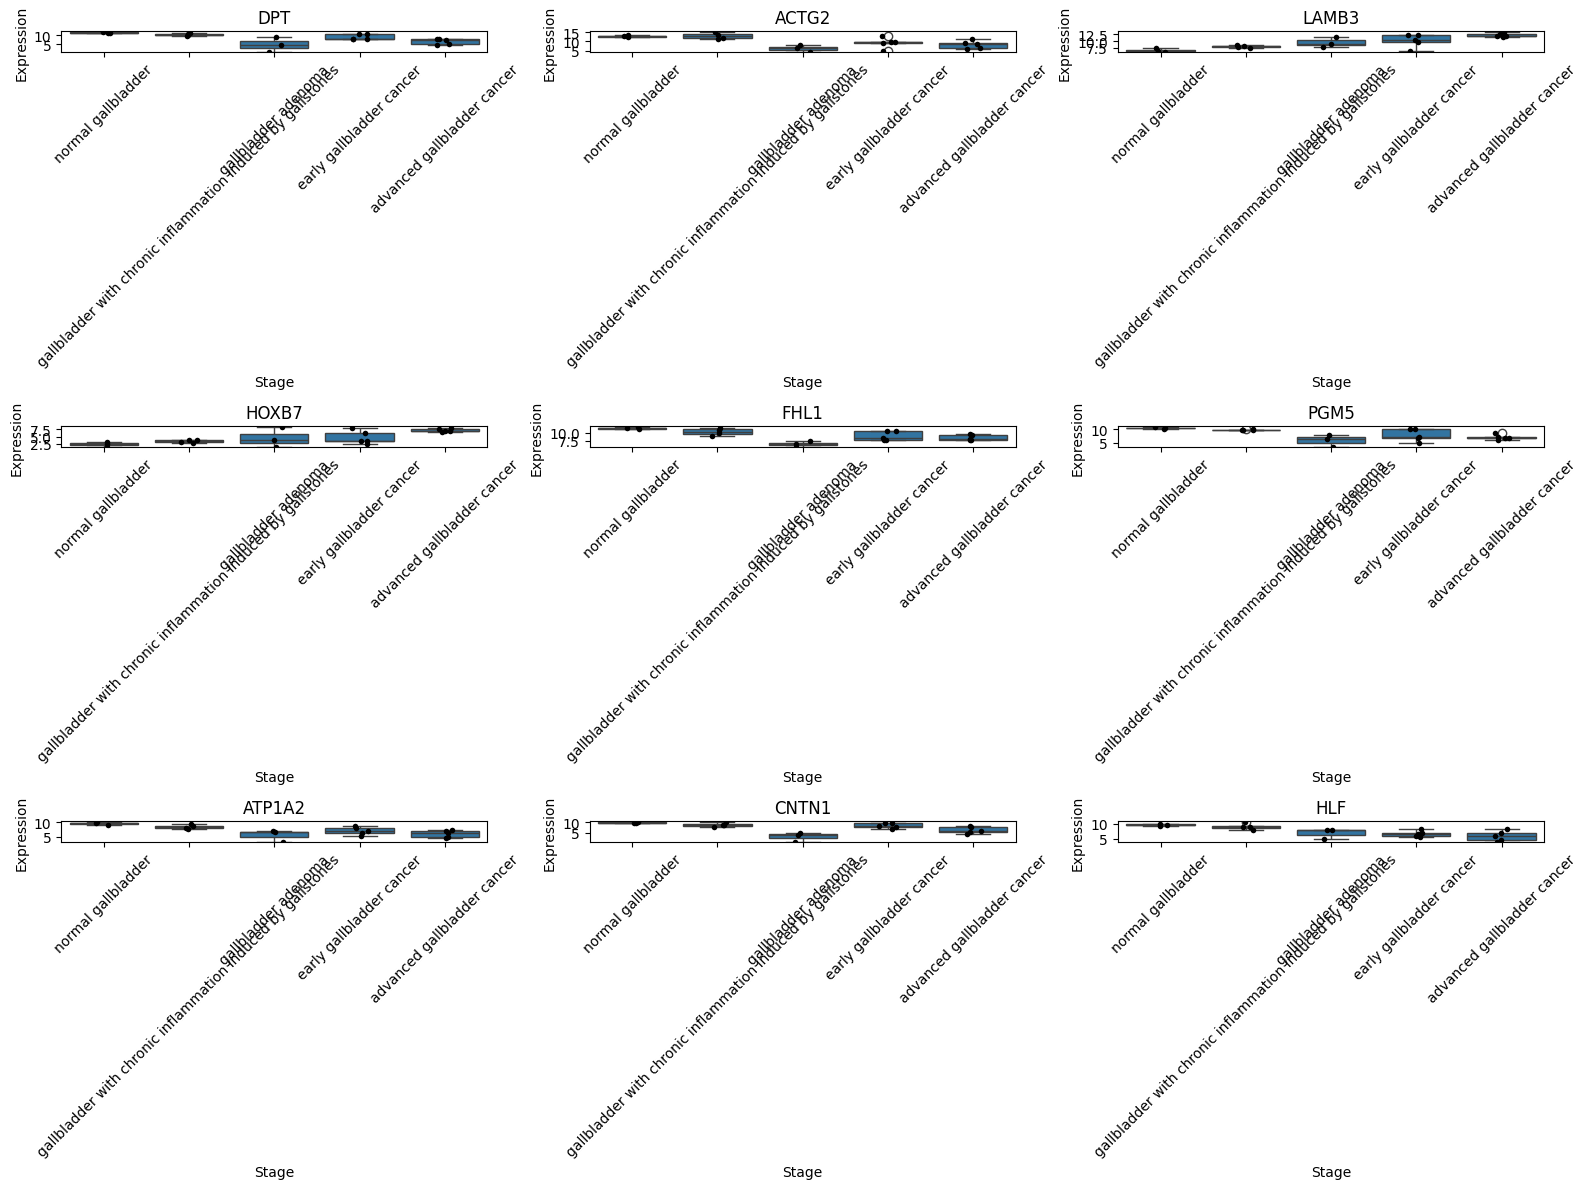

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rebuild full label map for GSE202479 (all 5 stages, not just normal/advanced)
titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

stage_map = {}
stage_order = ['normal gallbladder',
               'gallbladder with chronic inflammation induced by gallstones',
               'gallbladder adenoma',
               'early gallbladder cancer',
               'advanced gallbladder cancer']

for title, tissue in zip(titles, tissue_type):
    code = re.search(r'\[(.*?)\]', title).group(1)
    tissue_clean = tissue.replace('tissue type: ', '').strip()
    stage_map[code] = tissue_clean

# Build a dataframe: sample, stage, expression of each final-panel gene
final_panel = ['DPT', 'ACTG2', 'LAMB3', 'HOXB7', 'FHL1', 'PGM5', 'ATP1A2', 'CNTN1', 'HLF']

stage_expr_rows = []
for code, stage in stage_map.items():
    count_col = f"{code}_count"
    if count_col not in df_202479.columns:
        continue
    for gene in final_panel:
        row = df_202479_annot[df_202479_annot['Symbol'] == gene]
        if not row.empty:
            value = np.log2(row[count_col].values[0] + 1)
            stage_expr_rows.append({'Gene': gene, 'Stage': stage, 'Expression': value, 'Sample': code})

stage_df = pd.DataFrame(stage_expr_rows)
stage_df['Stage'] = pd.Categorical(stage_df['Stage'], categories=stage_order, ordered=True)

# Plot trend for each gene across stages
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, gene in enumerate(final_panel):
    gene_data = stage_df[stage_df['Gene'] == gene]
    sns.boxplot(data=gene_data, x='Stage', y='Expression', ax=axes[i])
    sns.stripplot(data=gene_data, x='Stage', y='Expression', ax=axes[i], color='black', size=4)
    axes[i].set_title(gene)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [40]:
# Check how many samples per stage, and mean expression per stage per gene
print(stage_df.groupby('Stage', observed=True)['Sample'].nunique())
print("\n")
print(stage_df.pivot_table(index='Stage', columns='Gene', values='Expression', aggfunc='mean', observed=True))

Stage
normal gallbladder                                             3
gallbladder with chronic inflammation induced by gallstones    4
gallbladder adenoma                                            3
early gallbladder cancer                                       5
advanced gallbladder cancer                                    5
Name: Sample, dtype: int64


Gene                                                    ACTG2    ATP1A2  \
Stage                                                                     
normal gallbladder                                  12.869393  9.550154   
gallbladder with chronic inflammation induced b...  13.007493  8.467283   
gallbladder adenoma                                  6.324147  5.615735   
early gallbladder cancer                             9.295565  7.112687   
advanced gallbladder cancer                          8.253394  5.922914   

Gene                                                   CNTN1        DPT  \
Stage                                  

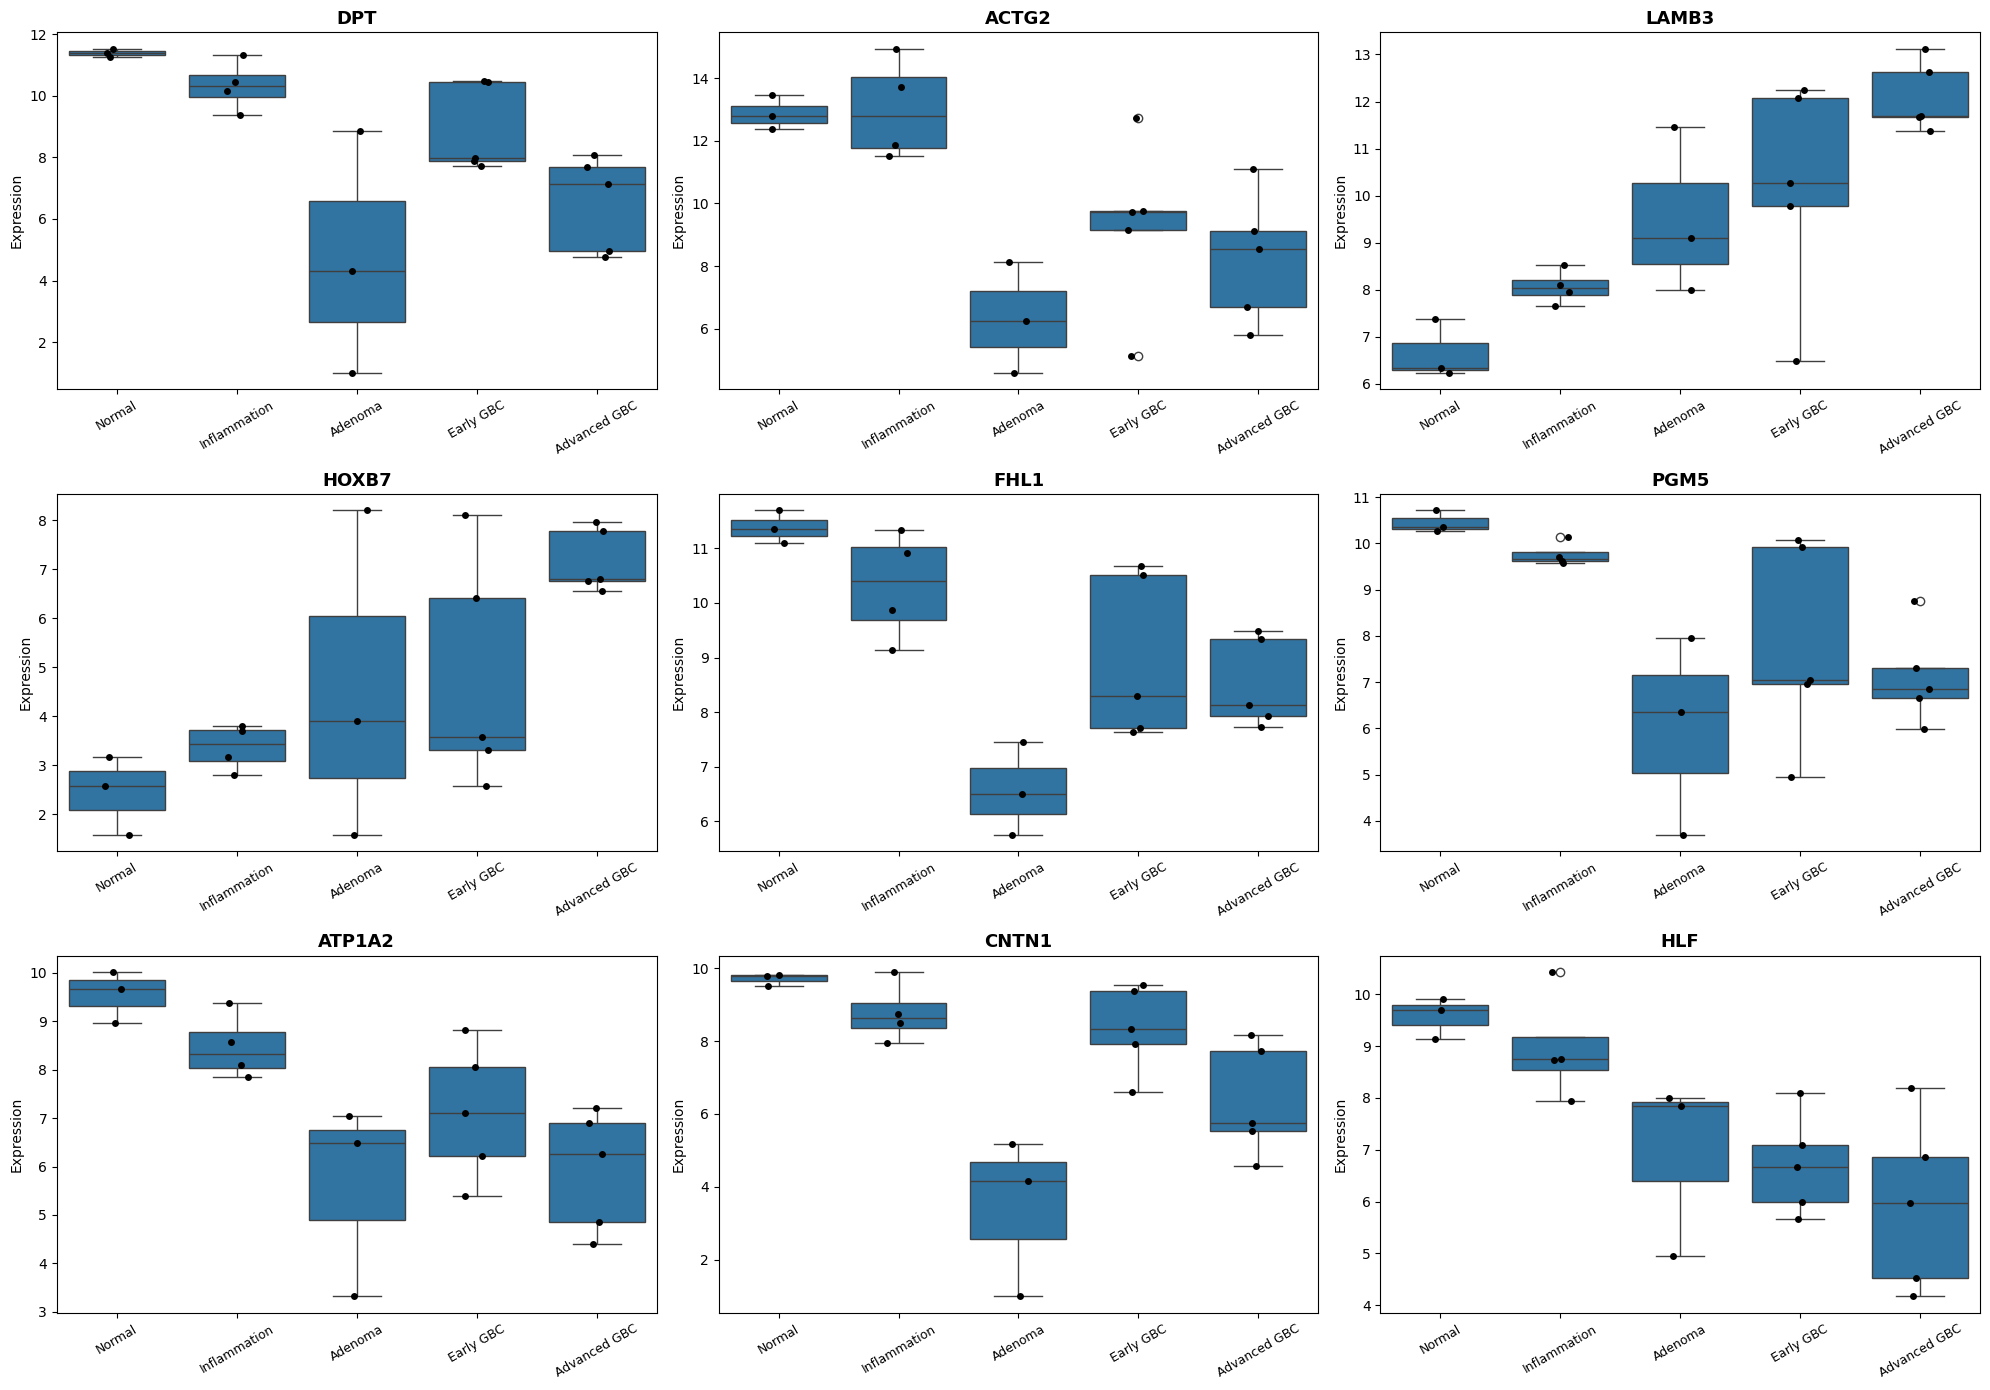

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Shorten stage names for readable x-axis labels
stage_rename = {
    'normal gallbladder': 'Normal',
    'gallbladder with chronic inflammation induced by gallstones': 'Inflammation',
    'gallbladder adenoma': 'Adenoma',
    'early gallbladder cancer': 'Early GBC',
    'advanced gallbladder cancer': 'Advanced GBC'
}
stage_order_short = ['Normal', 'Inflammation', 'Adenoma', 'Early GBC', 'Advanced GBC']

stage_df['Stage_Short'] = stage_df['Stage'].astype(str).map(stage_rename)
stage_df['Stage_Short'] = pd.Categorical(stage_df['Stage_Short'], categories=stage_order_short, ordered=True)

fig, axes = plt.subplots(3, 3, figsize=(20, 14))   # bigger figure size
axes = axes.flatten()
for i, gene in enumerate(final_panel):
    gene_data = stage_df[stage_df['Gene'] == gene]
    sns.boxplot(data=gene_data, x='Stage_Short', y='Expression', ax=axes[i])
    sns.stripplot(data=gene_data, x='Stage_Short', y='Expression', ax=axes[i], color='black', size=5)
    axes[i].set_title(gene, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)

plt.tight_layout()
plt.savefig('stage_progression_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# **Statistical Trend Test (Spearman Correlation**

In [42]:
from scipy.stats import spearmanr

# Assign a numeric stage order (0=Normal, 1=Inflammation, 2=Adenoma, 3=Early, 4=Advanced)
stage_numeric_map = {'Normal': 0, 'Inflammation': 1, 'Adenoma': 2, 'Early GBC': 3, 'Advanced GBC': 4}
stage_df['Stage_Numeric'] = stage_df['Stage_Short'].map(stage_numeric_map)

print("Gene\tSpearman_rho\tp-value")
for gene in final_panel:
    gene_data = stage_df[stage_df['Gene'] == gene]
    rho, pval = spearmanr(gene_data['Stage_Numeric'], gene_data['Expression'])
    print(f"{gene}\t{rho:.3f}\t\t{pval:.4f}")

Gene	Spearman_rho	p-value
DPT	-0.668		0.0013
ACTG2	-0.598		0.0053
LAMB3	0.813		0.0000
HOXB7	0.648		0.0020
FHL1	-0.496		0.0262
PGM5	-0.634		0.0027
ATP1A2	-0.694		0.0007
CNTN1	-0.536		0.0149
HLF	-0.744		0.0002


# **GO Biological Process + KEGG Pathway Enrichment**

In [44]:
!pip install gseapy --quiet
import gseapy as gp

final_panel = ['DPT', 'ACTG2', 'LAMB3', 'HOXB7', 'FHL1', 'PGM5', 'ATP1A2', 'CNTN1', 'HLF']

enr = gp.enrichr(
    gene_list=final_panel,
    gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human', 'GO_Molecular_Function_2023'],
    organism='human',
    outdir=None
)

results = enr.results.sort_values('Adjusted P-value')
print(results[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Genes']].head(20).to_string(index=False))

                  Gene_set                                                                                                          Term Overlap  Adjusted P-value  Genes
GO_Molecular_Function_2023                                                               P-type Sodium Transporter Activity (GO:0008554)     1/5          0.017522 ATP1A2
GO_Molecular_Function_2023                                          P-type Sodium:Potassium-Exchanging Transporter Activity (GO:0005391)     1/5          0.017522 ATP1A2
GO_Molecular_Function_2023                                                                               Sodium Ion Binding (GO:0031402)     1/6          0.017522 ATP1A2
GO_Molecular_Function_2023                                              P-type Potassium Transmembrane Transporter Activity (GO:0008556)     1/6          0.017522 ATP1A2
GO_Molecular_Function_2023                                                                            Potassium Ion Binding (GO:0030955)     1/9      

# **Enrichment on the LARGER 178-gene consensus pool (more statistical power)**

In [46]:
enr_full = gp.enrichr(
    gene_list=consensus_genes,   # full 178-gene list, not just final 9
    gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
    organism='human',
    outdir=None
)

results_full = enr_full.results.sort_values('Adjusted P-value')
# Filter to terms with multi-gene support (at least 3 genes overlapping)
results_full['Overlap_Count'] = results_full['Overlap'].apply(lambda x: int(x.split('/')[0]))
robust_results = results_full[results_full['Overlap_Count'] >= 3]

print(robust_results[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Genes']].head(20).to_string(index=False))

                  Gene_set                                                                                                          Term Overlap  Adjusted P-value                                                              Genes
GO_Biological_Process_2023                                                                               Muscle Contraction (GO:0006936)    9/94          0.000194                 TMOD1;RYR2;DTNA;SGCA;FXYD1;LMOD1;CASQ2;MYH11;CRYAB
           KEGG_2021_Human                                                                                        Dilated cardiomyopathy    8/96          0.000217                          RYR2;PLN;ACTC1;SGCA;ITGA8;ITGA7;DMD;ADCY5
           KEGG_2021_Human                                                                                    cGMP-PKG signaling pathway  10/167          0.000217         PLN;ADRB3;NPR1;KCNMB1;PDE2A;KCNMA1;ITPR1;ATP1A2;MYL9;ADCY5
           KEGG_2021_Human                                                      

# **Compare consensus genes with Khatun et al.'s hub genes**

In [47]:
khatun_genes = ['NTRK2', 'COL14A1', 'SCN4B', 'ATP1A2', 'SLC17A7', 'SLIT3',
                'COL7A1', 'CLDN4', 'CLEC3B', 'ADCYAP1R1', 'MFAP4']

overlap_with_khatun = set(consensus_genes) & set(khatun_genes)
print(f"Overlap with Khatun et al. (11 genes): {len(overlap_with_khatun)}")
print(overlap_with_khatun)

unique_to_yours = set(final_panel) - set(khatun_genes)
print(f"\nGenes in your final panel NOT in Khatun et al.: {unique_to_yours}")

Overlap with Khatun et al. (11 genes): 2
{'CLEC3B', 'ATP1A2'}

Genes in your final panel NOT in Khatun et al.: {'LAMB3', 'CNTN1', 'ACTG2', 'PGM5', 'DPT', 'HLF', 'FHL1', 'HOXB7'}


# **STRING PPI network visual polish**

In [48]:
# STEP 1: Fetch PPI network from STRING database for consensus genes

!pip install networkx requests --quiet

import requests
import pandas as pd
import networkx as nx

string_api_url = "https://string-db.org/api"
output_format = "tsv"
method = "network"

genes_string = "%0d".join(consensus_genes)  # 178 genes

params = {
    "identifiers": genes_string,
    "species": 9606,          # Homo sapiens
    "required_score": 700,     # high-confidence interactions only (0.7 threshold, standard practice)
}

request_url = f"{string_api_url}/{output_format}/{method}"
response = requests.post(request_url, data=params)

# Parse the interaction table
from io import StringIO
interactions = pd.read_csv(StringIO(response.text), sep='\t')
print(f"Total interactions found: {interactions.shape[0]}")
print(interactions[['preferredName_A', 'preferredName_B', 'score']].head())

Total interactions found: 211
  preferredName_A preferredName_B  score
0           HSPB6           HSPB8  0.793
1          TRIP13           BIRC5  0.716
2          TRIP13             TK1  0.722
3          TRIP13            BUB1  0.725
4          TRIP13           KIF14  0.744


In [49]:
# STEP 2: Build network graph and compute centrality measures

G = nx.Graph()
for _, row in interactions.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Three centrality measures (same as Khatun et al.'s approach)
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# MNC (Maximum Neighborhood Component) approximation:
# for each node, size of the largest connected component among its direct neighbors
def mnc_score(G, node):
    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        return 0
    subgraph = G.subgraph(neighbors)
    if subgraph.number_of_nodes() == 0:
        return 0
    components = list(nx.connected_components(subgraph))
    return max(len(c) for c in components) if components else 0

mnc_centrality = {node: mnc_score(G, node) for node in G.nodes()}

# STEP 3: Get top hub genes by each method, take intersection

top_n = 15

top_degree = set(sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:top_n])
top_closeness = set(sorted(closeness_centrality, key=closeness_centrality.get, reverse=True)[:top_n])
top_mnc = set(sorted(mnc_centrality, key=mnc_centrality.get, reverse=True)[:top_n])

hub_genes = top_degree & top_closeness & top_mnc
print(f"\nHub genes (top-{top_n} by all 3 centrality methods): {len(hub_genes)}")
print(hub_genes)

Network: 79 nodes, 211 edges

Hub genes (top-15 by all 3 centrality methods): 15
{'TRIP13', 'KIF14', 'MELK', 'KIF4A', 'ANLN', 'TOP2A', 'TTK', 'BUB1', 'EXO1', 'HMMR', 'NUF2', 'MKI67', 'CENPF', 'TPX2', 'BIRC5'}


In [50]:
# STEP 4: Compare PPI-based hub genes with your ML-based final panel and with Khatun et al.'s hub genes

final_panel = ['DPT', 'ACTG2', 'LAMB3', 'HOXB7', 'FHL1', 'PGM5', 'ATP1A2', 'CNTN1', 'HLF']
khatun_genes = ['NTRK2', 'COL14A1', 'SCN4B', 'ATP1A2', 'SLC17A7', 'SLIT3',
                'COL7A1', 'CLDN4', 'CLEC3B', 'ADCYAP1R1', 'MFAP4']

print("PPI hub genes ∩ your ML final panel:", hub_genes & set(final_panel))
print("PPI hub genes ∩ Khatun et al. genes:", hub_genes & set(khatun_genes))
print("\nAll PPI hub genes:", hub_genes)

PPI hub genes ∩ your ML final panel: set()
PPI hub genes ∩ Khatun et al. genes: set()

All PPI hub genes: {'TRIP13', 'KIF14', 'MELK', 'KIF4A', 'ANLN', 'TOP2A', 'TTK', 'BUB1', 'EXO1', 'HMMR', 'NUF2', 'MKI67', 'CENPF', 'TPX2', 'BIRC5'}


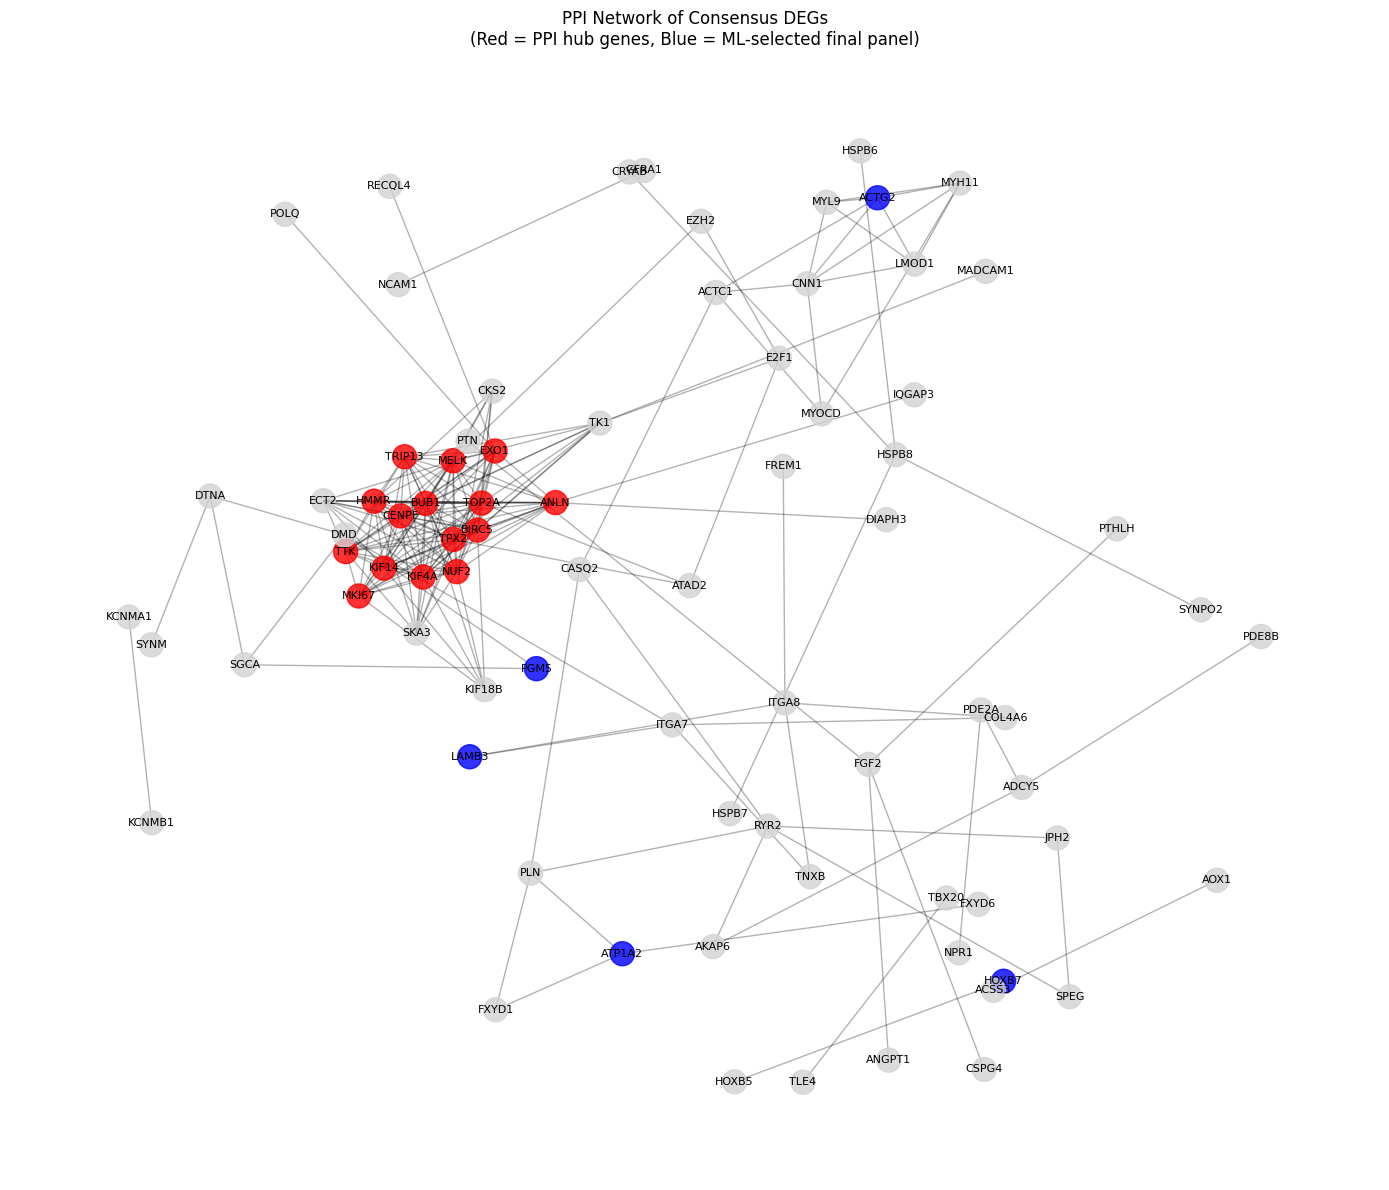

In [52]:
# Publication-quality PPI Network Visualization
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Color nodes: hub genes in red, final ML panel genes in blue, rest in gray
node_colors = []
for node in G.nodes():
    if node in hub_genes:
        node_colors.append('red')
    elif node in final_panel:
        node_colors.append('blue')
    else:
        node_colors.append('lightgray')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("PPI Network of Consensus DEGs\n(Red = PPI hub genes, Blue = ML-selected final panel)")
plt.axis('off')
plt.tight_layout()
plt.savefig('ppi_network.png', dpi=300, bbox_inches='tight')
plt.show()